----------------------------  Final Work --------------------------------------------


================= 🌱 PHASE 1 =================

📥 Data Preview:
   Temperature  Humidity  Light  Soil_Moisture     CO2  Growth
0        25.76     48.53   0.18           0.52  413.12   73.72
1        26.92     47.59   0.53           0.49  412.90   81.28
2        26.48     46.61   0.89           0.03  444.88   77.82
3        26.20     49.13   0.73           0.32  412.74   81.13
4        25.31     48.37   0.81           0.37  413.82   83.05
✅ Preprocessing done
✅ Data split completed
✅ Model trained

📊 Model Evaluation:
Train R2: 0.9971
Test  R2: 0.9781
MSE : 1.6239
RMSE: 1.2743
MAE : 1.0125
R2  : 0.9781
✅ Model looks balanced

🔁 Cross Validation R2 Scores: [0.98380975 0.98697519 0.98740265 0.98566579 0.97978337]
Average R2: 0.9847


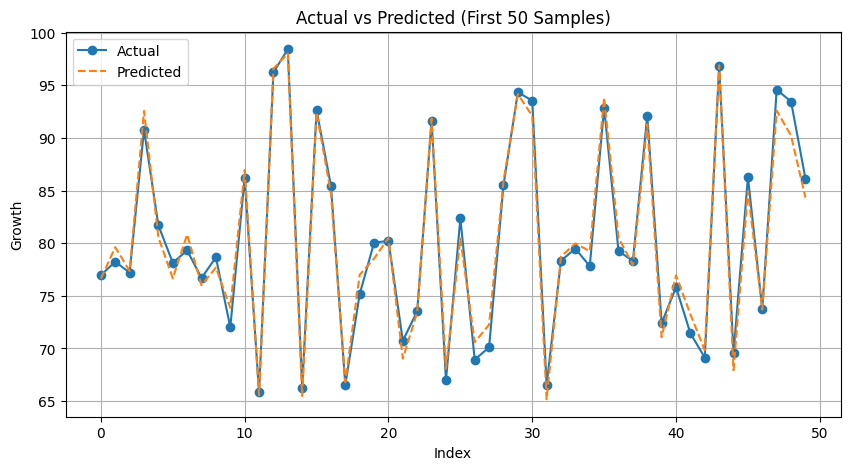


================= 🌱 PHASE 2 =================

📥 Data Preview:
   Temperature  Humidity   Light  Soil_Moisture     CO2  Growth
0        16.83     53.82  226.54          12.10  505.56   74.55
1        14.24     53.32  353.27          13.20  518.76   77.24
2        16.36     54.41  246.87          13.68  575.56   80.73
3        16.45     52.93  496.01          10.00  585.05   88.27
4        14.40     59.57  243.74          14.74  559.87   78.48
✅ Preprocessing done
✅ Data split completed
✅ Model trained

📊 Model Evaluation:
Train R2: 0.9966
Test  R2: 0.9551
MSE : 2.159
RMSE: 1.4694
MAE : 1.2099
R2  : 0.9551
✅ Model looks balanced

🔁 Cross Validation R2 Scores: [0.96405274 0.95582718 0.97733117 0.95593124 0.97015328]
Average R2: 0.9647


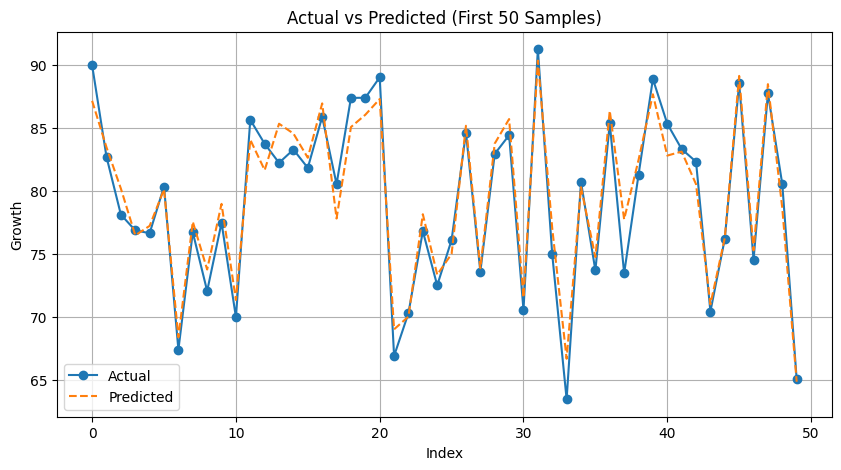


================= 🌱 PHASE 3 =================

📥 Data Preview:
   Temperature  Humidity    Light  Soil_Moisture     CO2  Growth
0        16.89     58.94  1129.90          25.53  719.46   78.91
1        16.44     63.57  1032.33          21.94  796.90   74.50
2        14.33     56.75  1935.55          23.24  755.17   82.23
3        14.40     60.43  1523.42          29.34  783.35   84.46
4        15.78     64.46  1543.35          21.43  735.41   80.15
✅ Preprocessing done
✅ Data split completed
✅ Model trained

📊 Model Evaluation:
Train R2: 0.9959
Test  R2: 0.9747
MSE : 1.6181
RMSE: 1.2721
MAE : 1.0553
R2  : 0.9747
✅ Model looks balanced

🔁 Cross Validation R2 Scores: [0.97338568 0.9740276  0.96902227 0.97543993 0.96973995]
Average R2: 0.9723


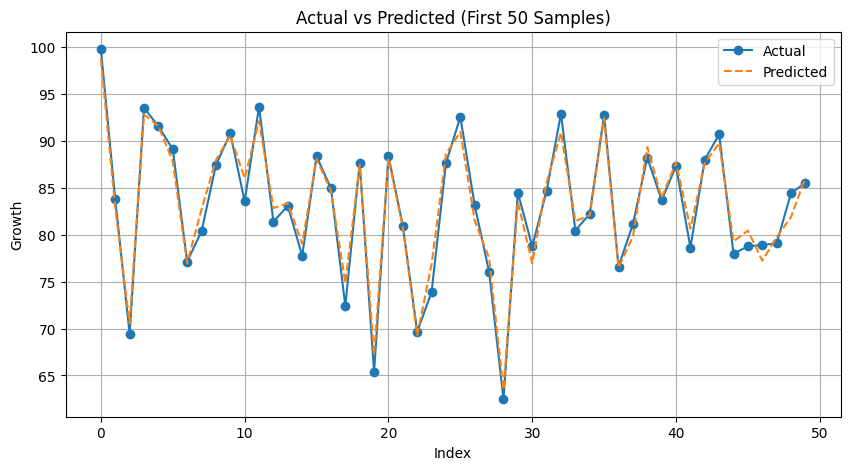


================= 🌱 PHASE 4 =================

📥 Data Preview:
   Temperature  Humidity    Light  Soil_Moisture     CO2  Growth
0        20.65     62.11  8505.68          48.88  991.47   91.17
1        21.39     66.49  5246.33          45.71  988.21   78.27
2        21.12     61.93  5849.66          43.75  963.53   74.66
3        20.59     66.15  5436.25          41.13  844.70   68.43
4        21.96     66.88  5020.15          49.66  904.18   80.51
✅ Preprocessing done
✅ Data split completed
✅ Model trained

📊 Model Evaluation:
Train R2: 0.9961
Test  R2: 0.9588
MSE : 2.5314
RMSE: 1.591
MAE : 1.1972
R2  : 0.9588
✅ Model looks balanced

🔁 Cross Validation R2 Scores: [0.96804574 0.97128938 0.96575815 0.9721137  0.96090752]
Average R2: 0.9676


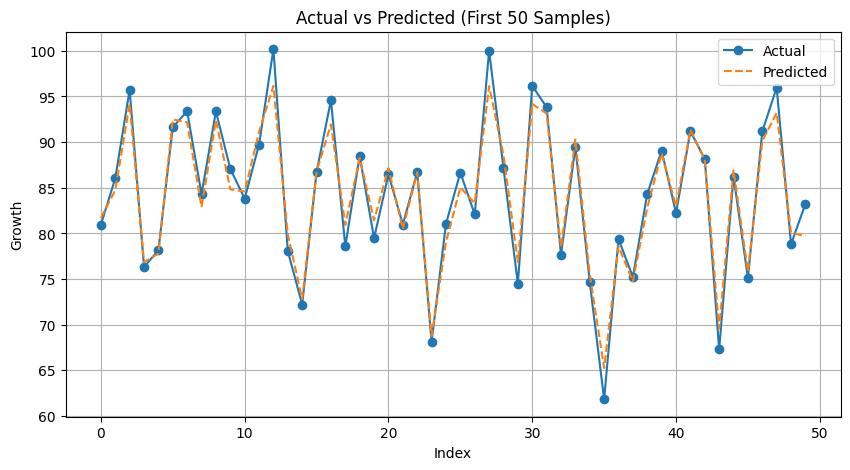


🏁 Final R2 Comparison Across Phases:
Phase 1 R2 Score: 0.9781
Phase 2 R2 Score: 0.9551
Phase 3 R2 Score: 0.9747
Phase 4 R2 Score: 0.9588


In [2]:
# ===================== IMPORT LIBRARIES =====================
import pandas as pd                     # For data handling
import numpy as np                      # For numerical operations
import matplotlib.pyplot as plt         # For plotting graphs

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


# ===================== CLASS DEFINITION =====================
class SaffronMLModel:
    
    def __init__(self, file_path):
        # Store dataset path
        self.file_path = file_path
        
        # Initialize variables
        self.df = None                  # Full dataset
        self.X = None                   # Features
        self.y = None                   # Target
        
        # Default ML model (you can change here)
        self.model = GradientBoostingRegressor(random_state=42)

    
    # ===================== LOAD DATA =====================
    def load_data(self):
        # Read CSV file
        self.df = pd.read_csv(self.file_path)
        
        # Show first few rows (optional)
        print("\n📥 Data Preview:")
        print(self.df.head())

    
    # ===================== PREPROCESSING =====================
    def preprocess(self):
        # Fill missing values using column mean
        self.df = self.df.fillna(self.df.mean())
        
        # Separate input features and target variable
        self.X = self.df.drop("Growth", axis=1)
        self.y = self.df["Growth"]
        
        print("✅ Preprocessing done")

    
    # ===================== TRAIN-TEST SPLIT =====================
    def split_data(self, test_size=0.2):
        # Split dataset into training and testing
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=test_size, random_state=42
        )
        
        print("✅ Data split completed")

    
    # ===================== MODEL TRAINING =====================
    def train(self):
        # Train model using training data
        self.model.fit(self.X_train, self.y_train)
        
        print("✅ Model trained")

    
    # ===================== MODEL EVALUATION =====================
    def evaluate(self):
        # Predict using test data
        self.y_pred = self.model.predict(self.X_test)
        
        # Calculate evaluation metrics
        mse = mean_squared_error(self.y_test, self.y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(self.y_test, self.y_pred)
        r2 = r2_score(self.y_test, self.y_pred)
        
        # Train vs Test score (important for overfitting check)
        train_r2 = self.model.score(self.X_train, self.y_train)
        test_r2  = self.model.score(self.X_test, self.y_test)
        
        # Print results
        print("\n📊 Model Evaluation:")
        print("Train R2:", round(train_r2, 4))
        print("Test  R2:", round(test_r2, 4))
        print("MSE :", round(mse, 4))
        print("RMSE:", round(rmse, 4))
        print("MAE :", round(mae, 4))
        print("R2  :", round(r2, 4))
        
        # Overfitting / Underfitting detection
        if train_r2 - test_r2 > 0.1:
            print("⚠️ Warning: Possible Overfitting")
        elif train_r2 < 0.5 and test_r2 < 0.5:
            print("⚠️ Warning: Underfitting")
        else:
            print("✅ Model looks balanced")
        
        return r2

    
    # ===================== CROSS VALIDATION =====================
    def cross_validate(self):
        # Perform 5-fold cross validation
        scores = cross_val_score(self.model, self.X, self.y, cv=5, scoring='r2')
        
        print("\n🔁 Cross Validation R2 Scores:", scores)
        print("Average R2:", round(scores.mean(), 4))

    
    # ===================== FEATURE IMPORTANCE =====================
    def feature_importance(self):
        # Get importance values
        importance = self.model.feature_importances_
        features = self.X.columns
        
        # Create sorted DataFrame
        importance_df = pd.DataFrame({
            "Feature": features,
            "Importance": importance
        }).sort_values(by="Importance", ascending=True)
        
        print("\n📊 Feature Importance:")
        print(importance_df)
        
        # Plot feature importance
        plt.figure()
        plt.barh(importance_df["Feature"], importance_df["Importance"])
        plt.title("Feature Importance")
        plt.show()

    
    # ===================== LINE PLOT =====================
    def compare_predictions(self):
        plt.figure(figsize=(10, 5))
        
        # Plot actual values
        plt.plot(self.y_test.values[:50], label="Actual", marker='o')
        
        # Plot predicted values
        plt.plot(self.y_pred[:50], label="Predicted", linestyle="dashed")
        
        plt.title("Actual vs Predicted (First 50 Samples)")
        plt.xlabel("Index")
        plt.ylabel("Growth")
        plt.legend()
        plt.grid(True)
        plt.show()

    
    # ===================== SCATTER PLOT =====================
    def plot_scatter(self):
        plt.figure(figsize=(6,6))
        
        # Scatter plot
        plt.scatter(self.y_test, self.y_pred, alpha=0.7)
        
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title("Actual vs Predicted Scatter")
        
        # Perfect prediction line
        plt.plot([self.y_test.min(), self.y_test.max()],
                 [self.y_test.min(), self.y_test.max()])
        
        plt.grid(True)
        plt.show()

    
    # ===================== RESIDUAL PLOT =====================
    def plot_residuals(self):
        # Calculate residuals
        residuals = self.y_test - self.y_pred
        
        plt.figure(figsize=(8,5))
        plt.scatter(self.y_pred, residuals)
        
        # Zero reference line
        plt.axhline(y=0)
        
        plt.xlabel("Predicted")
        plt.ylabel("Residuals")
        plt.title("Residual Plot")
        
        plt.grid(True)
        plt.show()

        def compare_models(self):
            print("\n🤖 Comparing Models...")

            # Define models
            models = {
                "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
                "Gradient Boosting": GradientBoostingRegressor(random_state=42),
                "XGBoost": XGBRegressor(random_state=42)
            }

            results = {}

            # Train & evaluate each model
            for name, model in models.items():
                model.fit(self.X_train, self.y_train)
                y_pred = model.predict(self.X_test)
                
                r2 = r2_score(self.y_test, y_pred)
                results[name] = r2
                
                print(f"{name} R2 Score: {round(r2, 4)}")

            # Find best model
            best_model_name = max(results, key=results.get)
            best_score = results[best_model_name]

            print("\n🏆 Best Model:", best_model_name)
            print("Best R2 Score:", round(best_score, 4))

            # Save best model
            self.model = models[best_model_name]


# ===================== MAIN EXECUTION =====================

# Create objects for each phase dataset
phase1 = SaffronMLModel(r"C:\Users\ASUS\OneDrive\Documents\Project_Saffon\datasets\phase1_saffron.csv")
phase2 = SaffronMLModel(r"C:\Users\ASUS\OneDrive\Documents\Project_Saffon\datasets\phase2_saffron.csv")
phase3 = SaffronMLModel(r"C:\Users\ASUS\OneDrive\Documents\Project_Saffon\datasets\phase3_saffron.csv")
phase4 = SaffronMLModel(r"C:\Users\ASUS\OneDrive\Documents\Project_Saffon\datasets\phase4_saffron.csv")

# Store all phases in list
phases = [phase1, phase2, phase3, phase4]

# Store results
results = []

# Run pipeline for each phase
for i, phase in enumerate(phases, start=1):
    print(f"\n================= 🌱 PHASE {i} =================")
    
    phase.load_data()
    phase.preprocess()
    phase.split_data()
    phase.train()
    
    r2 = phase.evaluate()         
    phase.cross_validate()
    phase.compare_predictions()
    
    # Optional:
    # phase.feature_importance()
    # phase.plot_scatter()
    # phase.plot_residuals()
    
    results.append(r2)

# Final comparison
print("\n🏁 Final R2 Comparison Across Phases:")
for i, r2 in enumerate(results, start=1):
    print(f"Phase {i} R2 Score: {round(r2, 4)}")